In [1]:
from functions.internal import load_dataset_1A, load_dataset_1B
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd

In [2]:
paysim, name, dimension, account_prop = load_dataset_1A()
paysim

First pass: Identifying users and fraud accounts...
Found 1026 unique users
Found 183 fraud accounts
Second pass: Processing transactions and building matrices...


,B5850430173,C0001731763,C0003913541,C0020644673,C0044341273,C0086812805,C0121278517,C0124661383,C0128381386,C0147974956,...,M9708361186,M9708630572,M9728330502,M9756176009,M9787222522,M9801367345,M9819595245,M9867675102,M9899701882,M9924470218
0,0.00,14693.17,59.89,57.04,39.89,76.68,3.70,377.39,58.0,16.77,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.00,14693.17,59.89,57.04,39.89,76.68,3.70,377.39,58.0,15626.35,...,0.00,0.00,0.00,-174728.25,0.00,0.00,0.00,-114650.19,-102698.39,0.00
2,0.00,14693.17,132112.55,57.04,39.89,76.68,3.70,377.39,58.0,15626.35,...,0.00,0.00,0.00,-174728.25,0.00,-202045.20,0.00,-114650.19,-102698.39,0.00
3,0.00,14693.17,132112.55,57.04,39.89,76.68,3.70,377.39,58.0,15626.35,...,0.00,0.00,0.00,-174728.25,0.00,-202045.20,0.00,-114650.19,-102698.39,0.00
4,0.00,14693.17,132112.55,57.04,39.89,76.68,3.70,377.39,58.0,15626.35,...,0.00,0.00,0.00,-174728.25,0.00,-202045.20,0.00,-114650.19,-102698.39,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,6964088.80,6575822.91,4679954.66,0.00,3783931.27,5007310.36,3717725.03,16347026.71,1072501.7,3620270.29,...,543231.19,-10808128.16,837738.38,-15602491.56,-8273742.46,-9877758.02,881367.39,-12075291.62,-12167706.57,772585.82
361,6967246.68,6575822.91,4679954.66,0.00,3783931.27,5007310.36,3717725.03,16347026.71,1072501.7,3620270.29,...,543231.19,-10808128.16,837738.38,836848.38,-8273742.46,-9877758.02,881367.39,-12075291.62,-12167706.57,-11790146.79
362,6967246.68,6575822.91,4679954.66,0.00,3783931.27,5007310.36,3717725.03,16347026.71,1072501.7,3620270.29,...,543231.19,-10808128.16,837738.38,836848.38,-8273742.46,-9877758.02,881367.39,-12075291.62,-12167706.57,-11790146.79
363,6967246.68,6575822.91,4679954.66,0.00,3783931.27,5007310.36,3717725.03,16347026.71,1072501.7,3620270.29,...,543231.19,-10808128.16,837738.38,836848.38,-8273742.46,-9877758.02,881367.39,-12075291.62,-12167706.57,-11790146.79


In [3]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import scienceplots
# plt.style.use('science')

# Flatten all residuals into a single array
all_data = paysim.values.flatten()

# # Plot distribution
# sns.histplot(all_data, kde=True)
# plt.title(f'Distribution of PaySim {dimension}')
# plt.show()

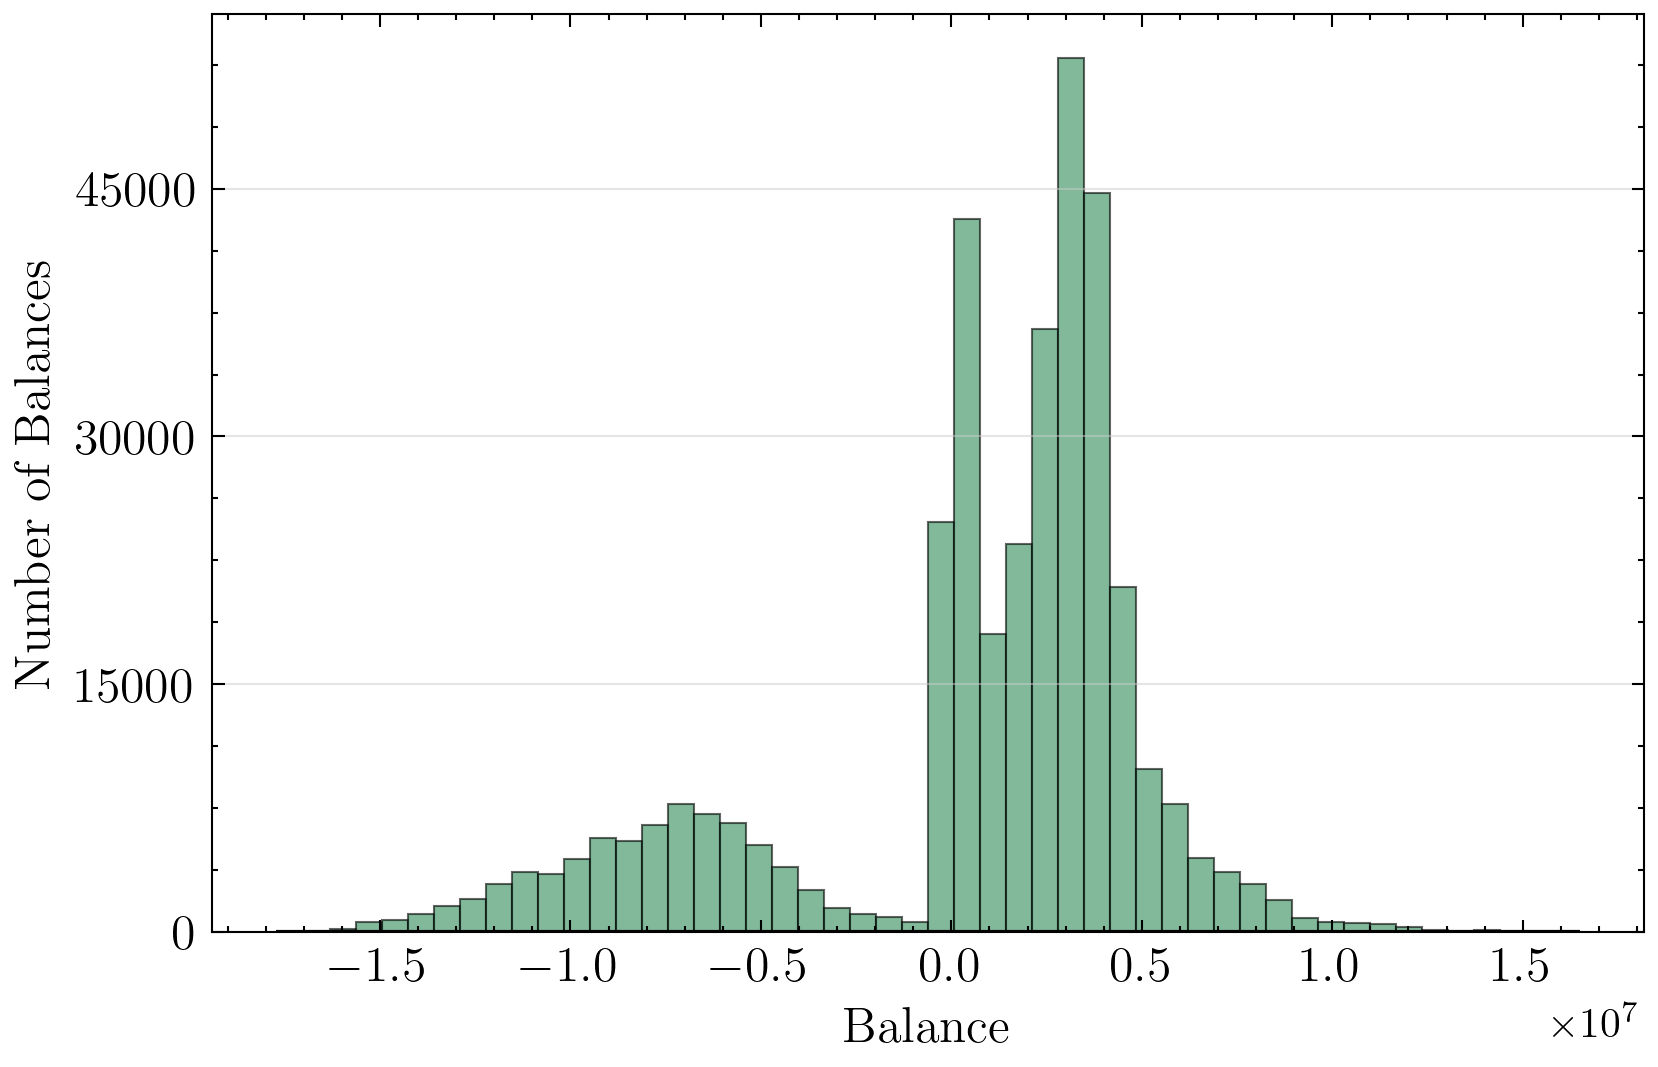

In [4]:
from scipy.stats import gaussian_kde
import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
from matplotlib.ticker import MaxNLocator

plt.style.use('science')

# --- Histogram parameters ---
bins = 50  # adjust to match Seaborn default feel
color_hist = '#2E8B57'  # standard blue is #4C72B0
alpha_hist = 0.6

# --- KDE curve ---
kde = gaussian_kde(all_data)
x_eval = np.linspace(all_data.min(), all_data.max(), 500)
kde_values = kde(x_eval)

# --- Figure size for thesis ---
cm = 1/2.54
fig_w_cm, fig_h_cm = 14, 9  # ~1.55 aspect
figsize = (fig_w_cm * cm, fig_h_cm * cm)

fig, ax = plt.subplots(figsize=figsize, constrained_layout=True, dpi=300)

# Histogram
density = False
ax.hist(all_data, bins=bins, density=False, alpha=alpha_hist,
        color=color_hist, edgecolor='black', linewidth=0.5)

# KDE curve
ax.plot(x_eval, kde_values, color='black', linewidth=1, label='KDE')

# Labels & aesthetics
ax.set_xlabel('Balance', fontsize=12)
if density:
        ax.set_ylabel('Density', fontsize=12)
else:
        ax.set_ylabel('Number of Balances', fontsize=12)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # at most 5 ticks

# Optional: light horizontal grid only
ax.grid(axis='y', color='#cccccc', linewidth=0.5, alpha=0.5)

# Save vector for thesis
plt.show()

In [5]:
Y, name, dimension, account_prop = load_dataset_1B()
Y

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,184.44,175.80,142.06,0.01,151.13,140.49,178.38,240.20,147.66,158.34,...,1970.87,2003.49,2021.47,1035.51,228.15,505.04,232.48,433.74,733.72,414.21
1,184.44,175.80,142.06,-125.87,151.13,140.49,178.38,240.20,147.66,158.34,...,3906.09,4247.91,3456.31,2473.23,629.74,863.83,277.24,697.62,1380.83,520.12
2,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,6453.45,7247.03,5578.29,4370.97,261.70,883.60,304.16,1307.15,1805.36,866.03
3,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,9015.04,10664.13,6756.00,5978.22,974.83,921.38,131.35,1516.45,2628.90,1610.57
4,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,11674.79,14435.14,9031.86,7597.62,1856.49,1098.21,618.02,1903.67,3546.84,698.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-2967.92,5052727.53,-2556.89,3005625.82,-2720.15,-2669.11,305465.58,2459.42,-425.25,-3324.70,...,11097918.04,12089534.68,14601036.72,34797516.99,9492793.06,10375104.27,13883185.18,21491333.73,14277318.48,19663746.89
196,-2967.92,5052727.53,-2556.89,3005625.82,-2720.15,-2669.11,305465.58,2329.10,-425.25,-3324.70,...,11100682.32,12092694.17,14603000.41,34798617.05,9493690.94,10375317.70,13883494.04,21491715.32,18981127.13,28210785.13
197,-2967.92,5052727.53,-2698.94,3005625.82,-2871.27,-2669.11,305465.58,2473.21,-425.25,-3324.70,...,11103791.12,12096145.37,25520923.82,34800442.38,9494511.40,10375612.51,15319097.36,21492112.69,25189362.25,32950725.75
198,-2967.92,5052727.53,-2840.99,3005625.82,-2871.27,-2669.11,305465.58,2473.21,-425.25,-3324.70,...,11106926.33,12099808.82,25522420.66,34802337.63,9495067.33,10375776.06,15319154.74,21492140.61,25187826.64,32951384.43


In [6]:
Y.shape

(200, 1000)

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Flatten all residuals into a single array
all_data = Y.values.flatten()

# Plot distribution
# sns.histplot(all_data, kde=True)
# plt.title(f'Distribution of AMLSim {dimension}')
# plt.show()

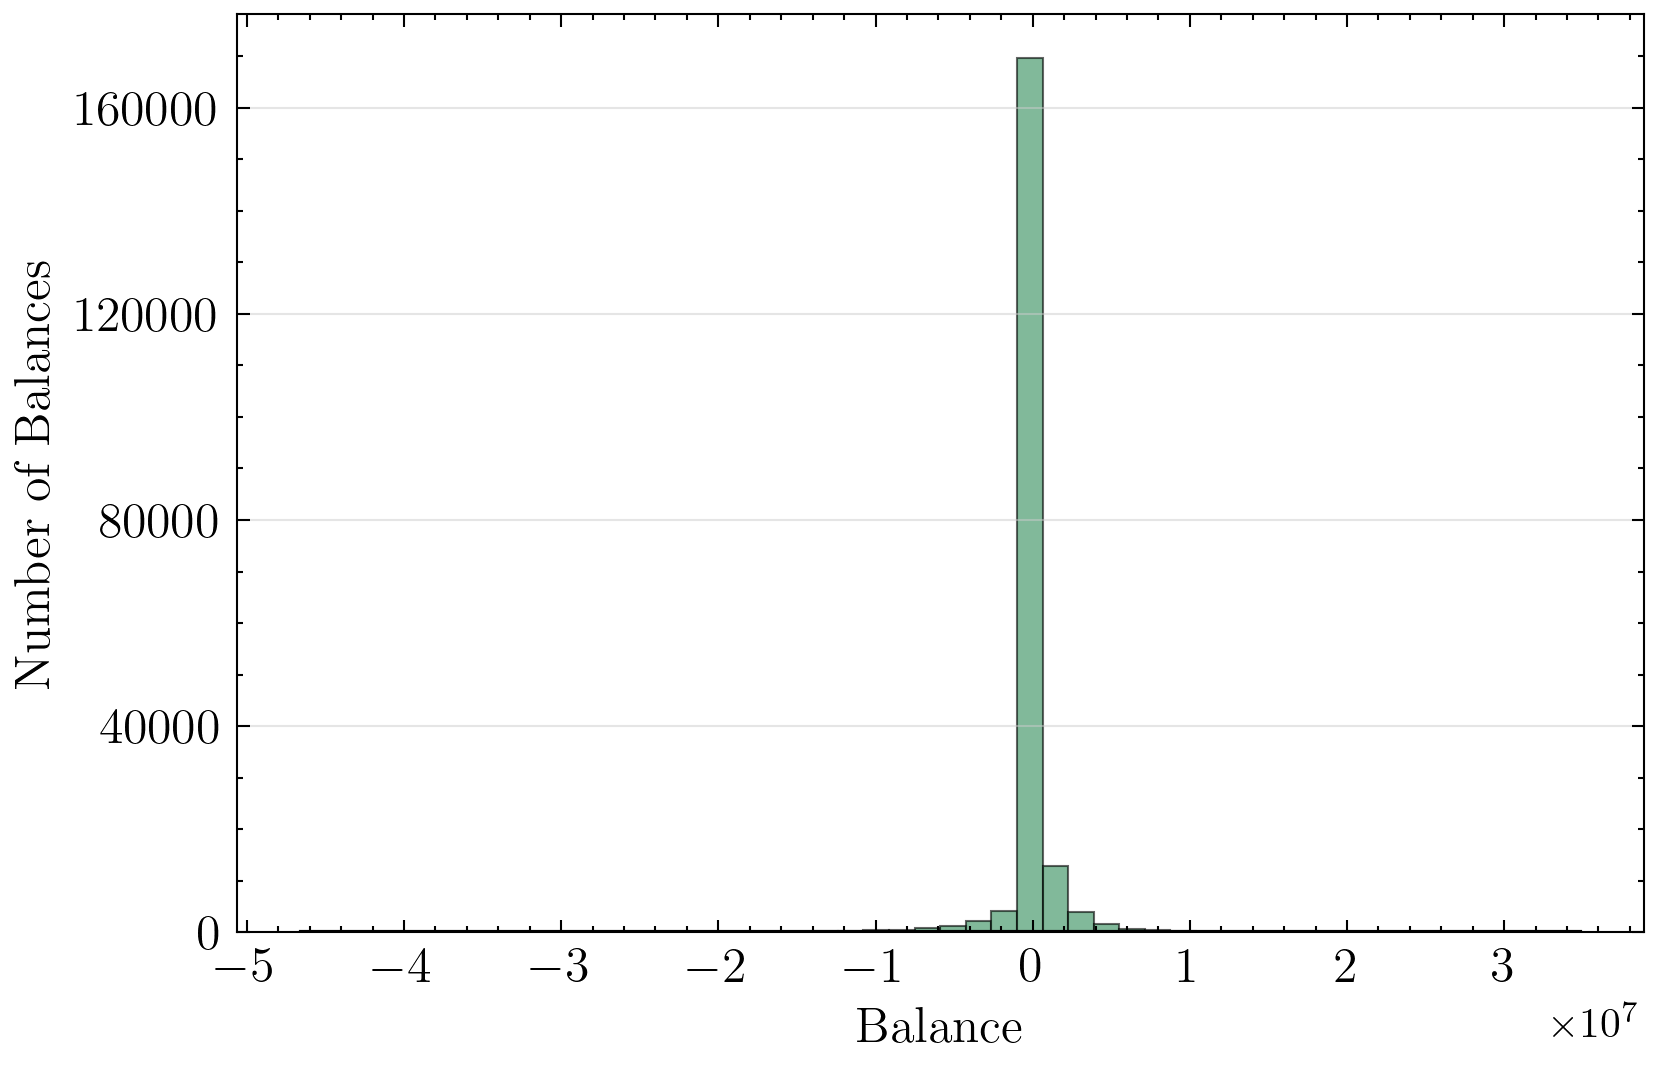

In [8]:
from scipy.stats import gaussian_kde
import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
from matplotlib.ticker import MaxNLocator

plt.style.use('science')

# --- Histogram parameters ---
bins = 50  # adjust to match Seaborn default feel
color_hist = '#2E8B57'  # standard blue is #4C72B0
alpha_hist = 0.6

# --- KDE curve ---
kde = gaussian_kde(all_data)
x_eval = np.linspace(all_data.min(), all_data.max(), 500)
kde_values = kde(x_eval)

# --- Figure size for thesis ---
cm = 1/2.54
fig_w_cm, fig_h_cm = 14, 9  # ~1.55 aspect
figsize = (fig_w_cm * cm, fig_h_cm * cm)

fig, ax = plt.subplots(figsize=figsize, constrained_layout=True, dpi=300)

# Histogram
density = False
ax.hist(all_data, bins=bins, density=density, alpha=alpha_hist,
        color=color_hist, edgecolor='black', linewidth=0.5)

# KDE curve
ax.plot(x_eval, kde_values, color='black', linewidth=1, label='KDE')

# Labels & aesthetics
ax.set_xlabel('Balance', fontsize=12)
if density:
        ax.set_ylabel('Density', fontsize=12)
else:
        ax.set_ylabel('Number of Balances', fontsize=12)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # at most 5 ticks

# Optional: light horizontal grid only
ax.grid(axis='y', color='#cccccc', linewidth=0.5, alpha=0.5)

# Save vector for thesis
plt.show()

In [7]:
results = {}

for user in Y.columns:
    series = Y[user].dropna()  # Drop missing values if any
    result = acorr_ljungbox(series, lags=[10], return_df=True)
    results[user] = result["lb_pvalue"].values[0]  # Get p-value for lag=10

# Convert to a DataFrame for easier inspection
ljungbox_df = pd.DataFrame.from_dict(results, orient='index', columns=['lb_pvalue'])

# Identify users with p < 0.05 (reject independence → not i.i.d.)
non_iid_users = ljungbox_df[ljungbox_df['lb_pvalue'] < 0.05]
print(non_iid_users.shape)

(100, 1)


In [8]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

results = {}

for user in Y.columns:
    series = Y[user].dropna()
    try:
        adf_result = adfuller(series)
    except:
        pass
    adf_stat = adf_result[0]      # ADF test statistic
    p_value = adf_result[1]       # p-value
    results[user] = p_value       # or (adf_stat, p_value) if you want both

# Convert to DataFrame
adfuller_df = pd.DataFrame.from_dict(results, orient='index', columns=['p_value'])

# Identify users with p >= 0.05 → non-stationary → not identically distributed
non_stationary_users = adfuller_df[adfuller_df['p_value'] >= 0.05]
print(non_stationary_users)

     p_value
0   0.741066
1   0.908294
2   0.946244
3   0.879765
5   0.138760
..       ...
95  0.994581
96  0.881649
97  0.995076
98  0.990835
99  0.972739

[93 rows x 1 columns]


# Redsidual

In [9]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np

In [10]:
dim = '100'
SEASONAL_PERIOD = 7

Reading transactions from 'Datasets/AMLSim/100 users/transactions.csv'.
Aggregate transactions to create daily net change for each account...
Time series matrix: 200 days x 100 accounts.
-> Plotting line graph of all processed account time series...


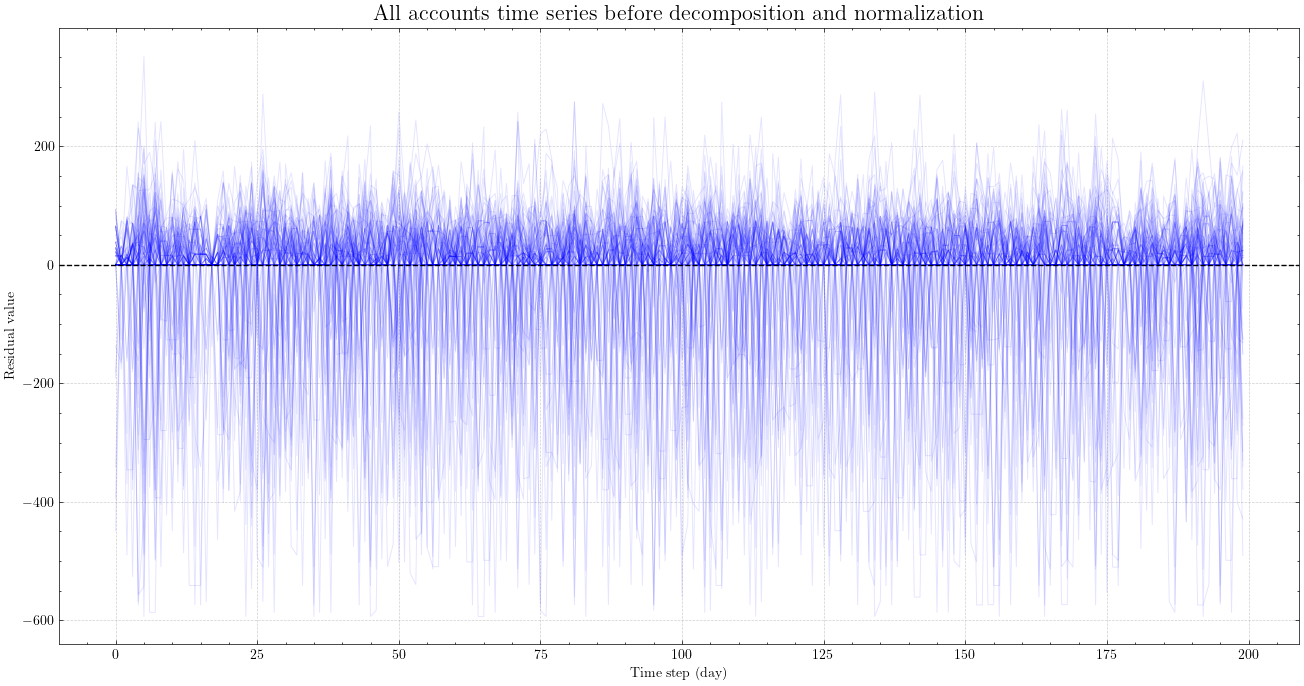

Remove patterns for days=7 to find residuals.
Data with 194 samples after decomposition.
Plotting time series for most volatile account: 45


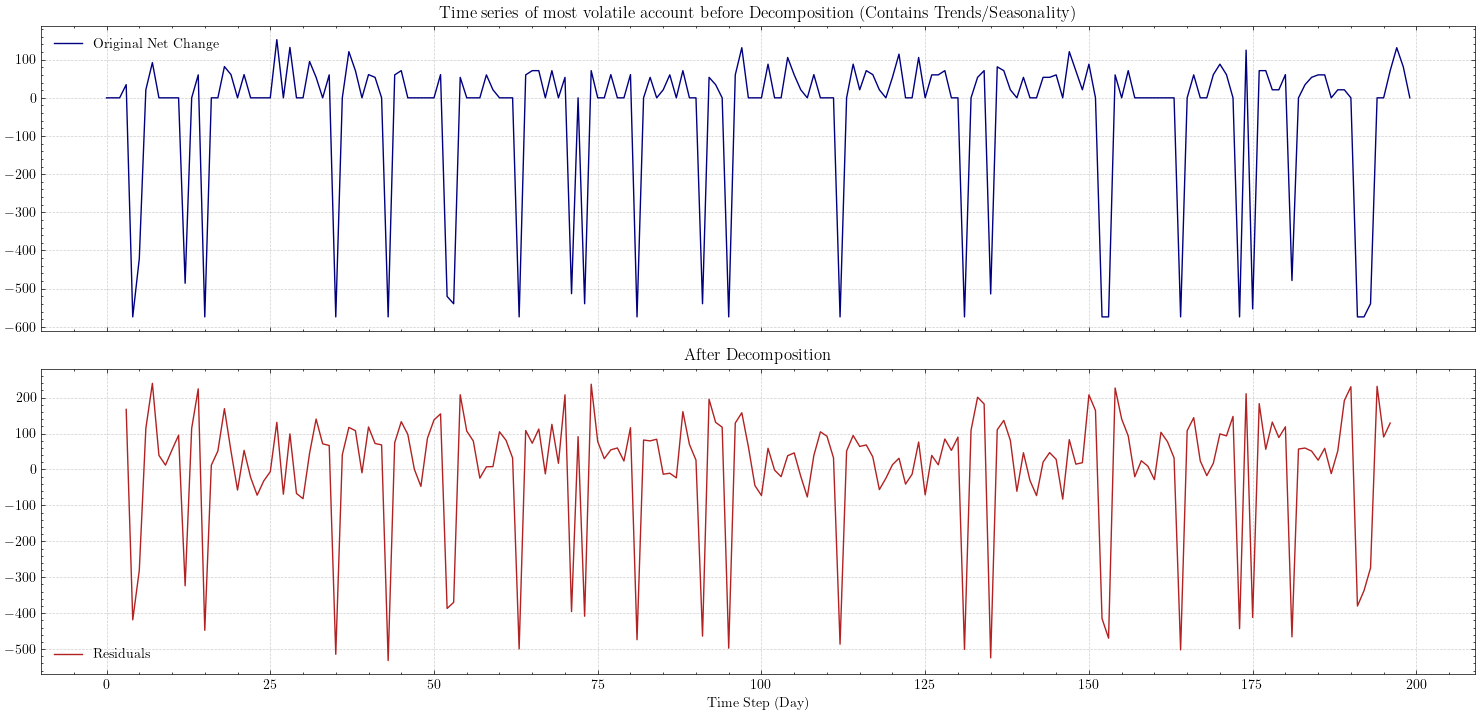

-> Standardizing (normalizing) data...
-> Plotting line graph of all processed account time series...


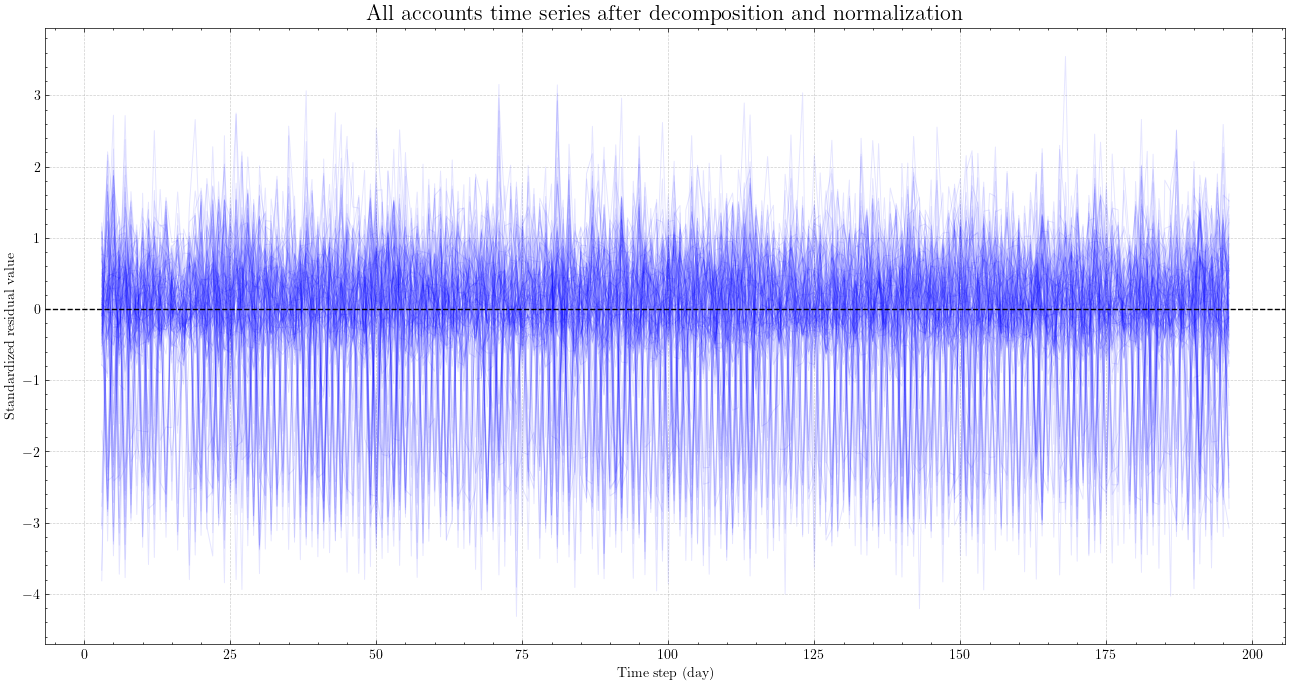

Number of non independent users is 100
Number of non stationary users is 0


In [11]:
TRANSACTION_FILE = f'Datasets/AMLSim/{dim} users/transactions.csv'
print(f"Reading transactions from '{TRANSACTION_FILE}'.")
df_raw = pd.read_csv(TRANSACTION_FILE)    

# Create a daily net change time series ---
print("Aggregate transactions to create daily net change for each account...")

daily_sent     = df_raw.groupby(['TIMESTAMP', 'SENDER_ACCOUNT_ID'])['TX_AMOUNT'].sum().unstack(fill_value=0)
daily_received = df_raw.groupby(['TIMESTAMP', 'RECEIVER_ACCOUNT_ID'])['TX_AMOUNT'].sum().unstack(fill_value=0)

all_accounts = sorted(list(set(daily_sent.columns) | set(daily_received.columns)))
all_days     = range(df_raw['TIMESTAMP'].min(), df_raw['TIMESTAMP'].max() + 1)

daily_sent     = daily_sent.reindex(index=all_days, columns=all_accounts, fill_value=0)
daily_received = daily_received.reindex(index=all_days, columns=all_accounts, fill_value=0)

df_net_change = daily_received - daily_sent
print(f"Time series matrix: {df_net_change.shape[0]} days x {df_net_change.shape[1]} accounts.")

# print("-> Plotting line graph of all processed account time series...")
# plt.figure(figsize=(16, 8))
# plt.plot(df_net_change.index, df_net_change, color='blue', alpha=0.1, linewidth=0.7)
# plt.title('All accounts time series before decomposition and normalization', fontsize=16)
# plt.xlabel('Time step (day)')
# plt.ylabel('Residual value')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.axhline(0, color='black', linestyle='--', linewidth=1) # Add a line at zero
# plt.show()

print(f"Remove patterns for days={SEASONAL_PERIOD} to find residuals.")

if len(df_net_change) <= 2 * SEASONAL_PERIOD:
    print(f"Not enough days in the dataset. Use net changes directly.")
    df_residuals = df_net_change
else: 
    # check the options here: https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html
    all_residuals = { 
        account: seasonal_decompose(df_net_change[account], model='additive', period=SEASONAL_PERIOD).resid
        for account in df_net_change.columns
    }
    df_residuals = pd.DataFrame(all_residuals).dropna()
    print(f"Data with {df_residuals.shape[0]} samples after decomposition.")

most_volatile_account = df_net_change.var().idxmax()
print(f"Plotting time series for most volatile account: {most_volatile_account}")

# fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
# axes[0].plot(df_net_change.index, df_net_change[most_volatile_account], label='Original Net Change', color='navy')
# axes[0].set_title('Time series of most volatile account before Decomposition (Contains Trends/Seasonality)')
# axes[0].grid(True, linestyle='--', alpha=0.6)
# axes[0].legend()
# axes[1].plot(df_residuals.index, df_residuals[most_volatile_account], label='Residuals', color='firebrick')
# axes[1].set_title('After Decomposition')
# axes[1].set_xlabel('Time Step (Day)')
# axes[1].grid(True, linestyle='--', alpha=0.6)
# axes[1].legend()
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()


print("-> Standardizing (normalizing) data...")
residuals_matrix = df_residuals.values
col_std = np.std(residuals_matrix, axis=0, keepdims=True)
col_std[col_std == 0] = 1.0
prepared_data = residuals_matrix / col_std

# print("-> Plotting line graph of all processed account time series...")
# plt.figure(figsize=(16, 8))
# plt.plot(df_residuals.index, prepared_data, color='blue', alpha=0.1, linewidth=0.7)
# plt.title('All accounts time series after decomposition and normalization', fontsize=16)
# plt.xlabel('Time step (day)')
# plt.ylabel('Standardized residual value')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.axhline(0, color='black', linestyle='--', linewidth=1) # Add a line at zero
# plt.show()

In [12]:
# Load your CSV
transactions = pd.read_csv(TRANSACTION_FILE)

# Create a normalized user-pair column (sorted to ignore direction)
transactions['USER_PAIR'] = transactions.apply(
    lambda row: tuple(sorted([row['SENDER_ACCOUNT_ID'], row['RECEIVER_ACCOUNT_ID']])), axis=1
)

# Count the number of transactions per pair
pair_counts = transactions.groupby('USER_PAIR').size().reset_index(name='TX_COUNT')

# Filter for pairs with more than one transaction
repeated_pairs = pair_counts[pair_counts['TX_COUNT'] > 1]

print("User pairs with multiple interactions (in any direction):")
print(repeated_pairs)

User pairs with multiple interactions (in any direction):
    USER_PAIR  TX_COUNT
0     (0, 21)        23
1     (0, 53)        13
2     (0, 87)        21
3     (0, 96)        21
4     (1, 48)        26
..        ...       ...
797  (97, 97)        23
798  (97, 98)        22
799  (97, 99)        23
800  (98, 99)        39
801  (99, 99)        17

[801 rows x 2 columns]


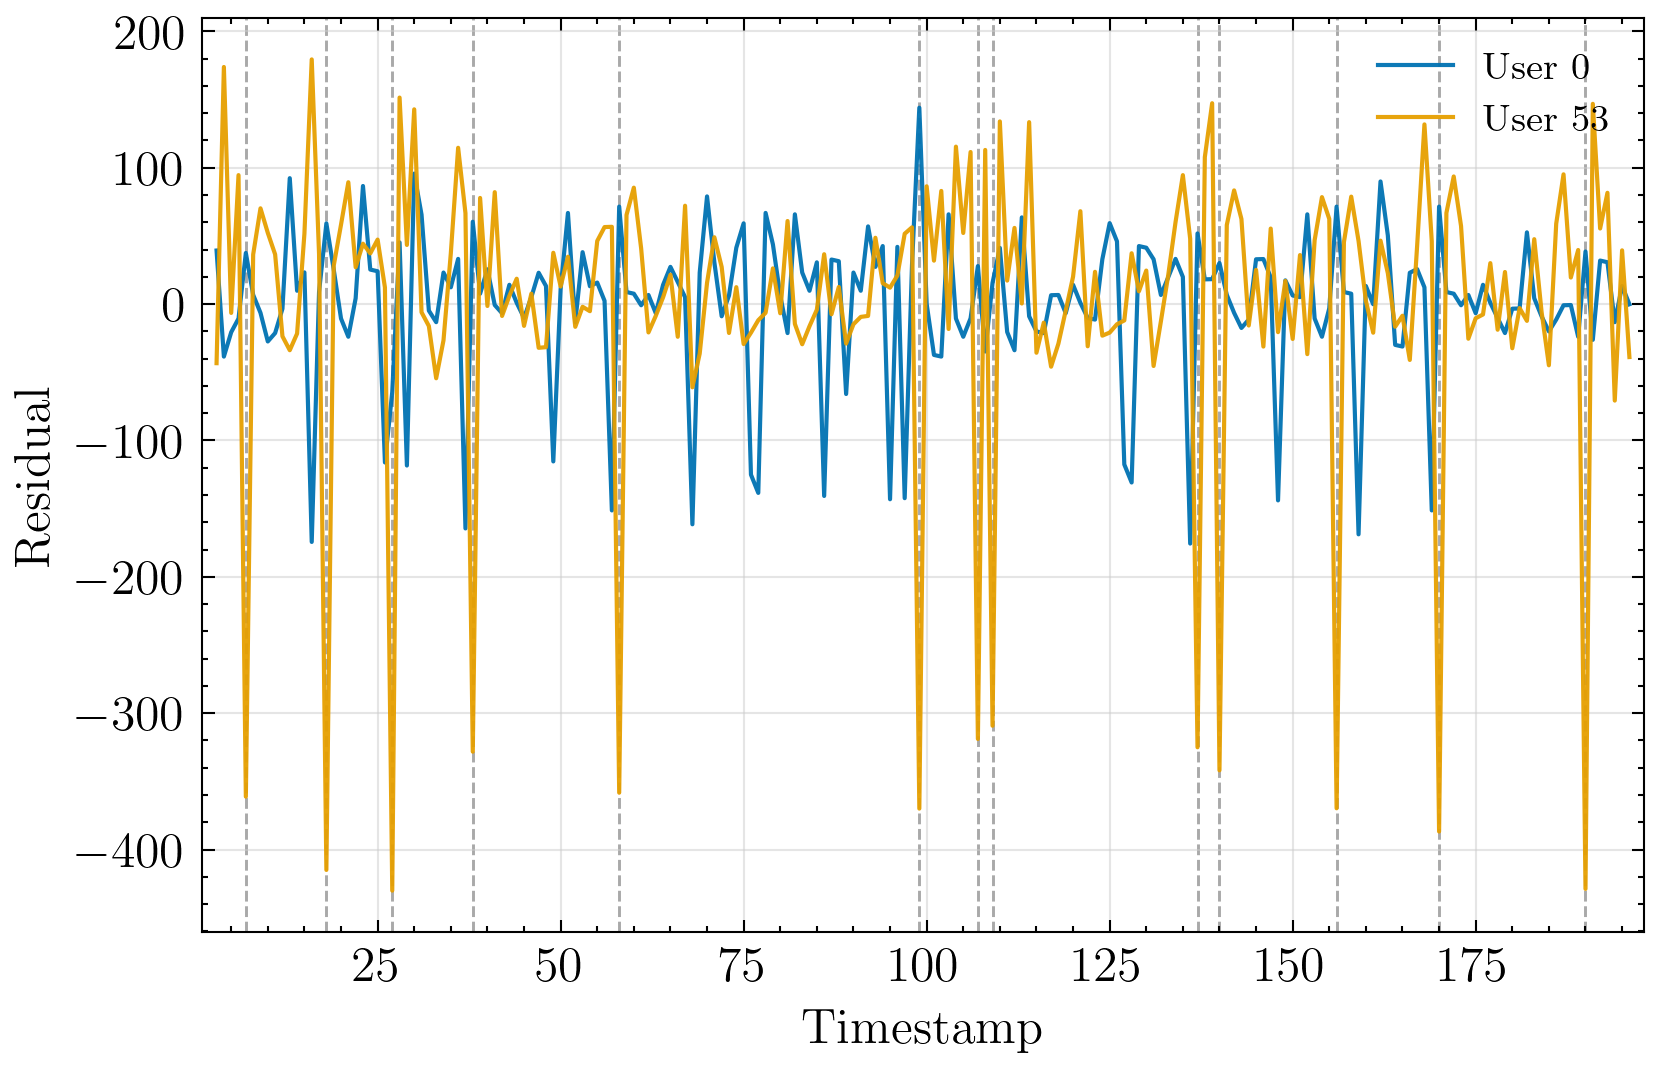

In [45]:
user_a = 0
user_b = 53

# Thesis-friendly sizing: ~14 cm × 9 cm (≈ 1.55:1)
cm = 1 / 2.54
fig_w_cm, fig_h_cm = 14, 9
figsize = (fig_w_cm * cm, fig_h_cm * cm)

# Color-blind–safe colors (Tol palette)
C_A = '#0072B2'  # blue
C_B = '#E69F00'  # orange
C_EVT = '#A0A0A0'   # neutral gray for events

# Typography hierarchy (will be scaled by the backend)
rc = {
    'font.size': 12,            # ticks
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'lines.linewidth': 1,
    'grid.color': '#cccccc',
    'grid.linewidth': 0.6,
}
plt.rcParams.update(rc)

# ----------------------------- Data prep ----------------------------------
series_a = df_residuals[user_a].dropna()
series_b = df_residuals[user_b].dropna()

# Filter mutual transactions between the two users
mutual_tx = transactions[
    ((transactions['SENDER_ACCOUNT_ID'] == user_a) & (transactions['RECEIVER_ACCOUNT_ID'] == user_b)) |
    ((transactions['SENDER_ACCOUNT_ID'] == user_b) & (transactions['RECEIVER_ACCOUNT_ID'] == user_a))
]

# Align mutual transaction timestamps to the index dtype of the series
idx = series_a.index  # assume both series share the same x-index domain
ts = mutual_tx['TIMESTAMP']

if np.issubdtype(getattr(idx, 'dtype', np.dtype('O')), np.datetime64):
    ts_aligned = pd.to_datetime(ts, errors='coerce')
else:
    # Try numeric; fall back to original if coercion fails
    ts_numeric = pd.to_numeric(ts, errors='coerce')
    ts_aligned = ts_numeric if ts_numeric.notna().any() else ts

# Deduplicate + sort
mutual_timestamps = pd.Index(ts_aligned.dropna().unique())
try:
    mutual_timestamps = mutual_timestamps.sort_values()
except Exception:
    pass  # keep as-is if not sortable

# ------------------------------- Plot -------------------------------------
fig, ax = plt.subplots(figsize=figsize, constrained_layout=True, dpi=300)

# Main series
ax.plot(series_a.index, series_a.values, label=f'User {user_a}', color=C_A, alpha=0.95)
ax.plot(series_b.index, series_b.values, label=f'User {user_b}', color=C_B, alpha=0.95)

# Subtle event markers behind data (thin, semi-transparent, clipped to axes)
ymin, ymax = ax.get_ylim()
for t in mutual_timestamps:
    ax.axvline(x=t, color=C_EVT, linestyle='--', lw=0.7, alpha=0.9, zorder=0)

# Labels & cosmetics
ax.set_xlabel('Timestamp')          
ax.set_ylabel('Residual')      
ax.grid(axis='y', color='#cccccc', linewidth=0.5, alpha=0.5)
ax.grid(axis='x', color='#cccccc', linewidth=0.5, alpha=0.5, visible=True)
ax.legend(loc='upper right', framealpha=0.85)
ax.margins(x=0.01)                  # minimal horizontal padding

plt.show()

In [46]:
# user_a = 0
# user_b = 53

# series_a = df_residuals[user_a].dropna()
# series_b = df_residuals[user_b].dropna()


# # Filter mutual transactions
# mutual_tx = transactions[
#     ((transactions['SENDER_ACCOUNT_ID'] == user_a) & (transactions['RECEIVER_ACCOUNT_ID'] == user_b)) |
#     ((transactions['SENDER_ACCOUNT_ID'] == user_b) & (transactions['RECEIVER_ACCOUNT_ID'] == user_a))
# ]

# # Get the unique timestamps (assuming 'TIMESTAMP' is numeric or datetime)
# mutual_timestamps = mutual_tx['TIMESTAMP'].unique()

# # Make sure timestamps are in the index format of the series (if needed)
# # You may need to align formats if residuals use datetime or int indices

# # Now plot with highlights
# plt.figure(figsize=(12, 7.5), dpi=180)
# plt.plot(series_a, label=f"User {user_a}", alpha=0.7, color='green')
# plt.plot(series_b, label=f"User {user_b}", alpha=0.7, color='orange')

# # Highlight mutual transaction timestamps
# for t in mutual_timestamps:
#     plt.axvline(x=t, color='red', linestyle='--', alpha=0.4)

# plt.legend()
# plt.title(f"Residual Time Series: User {user_a} vs User {user_b}\n(red lines = mutual transactions)")
# plt.xlabel("Timestamp")
# plt.ylabel("Residual")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


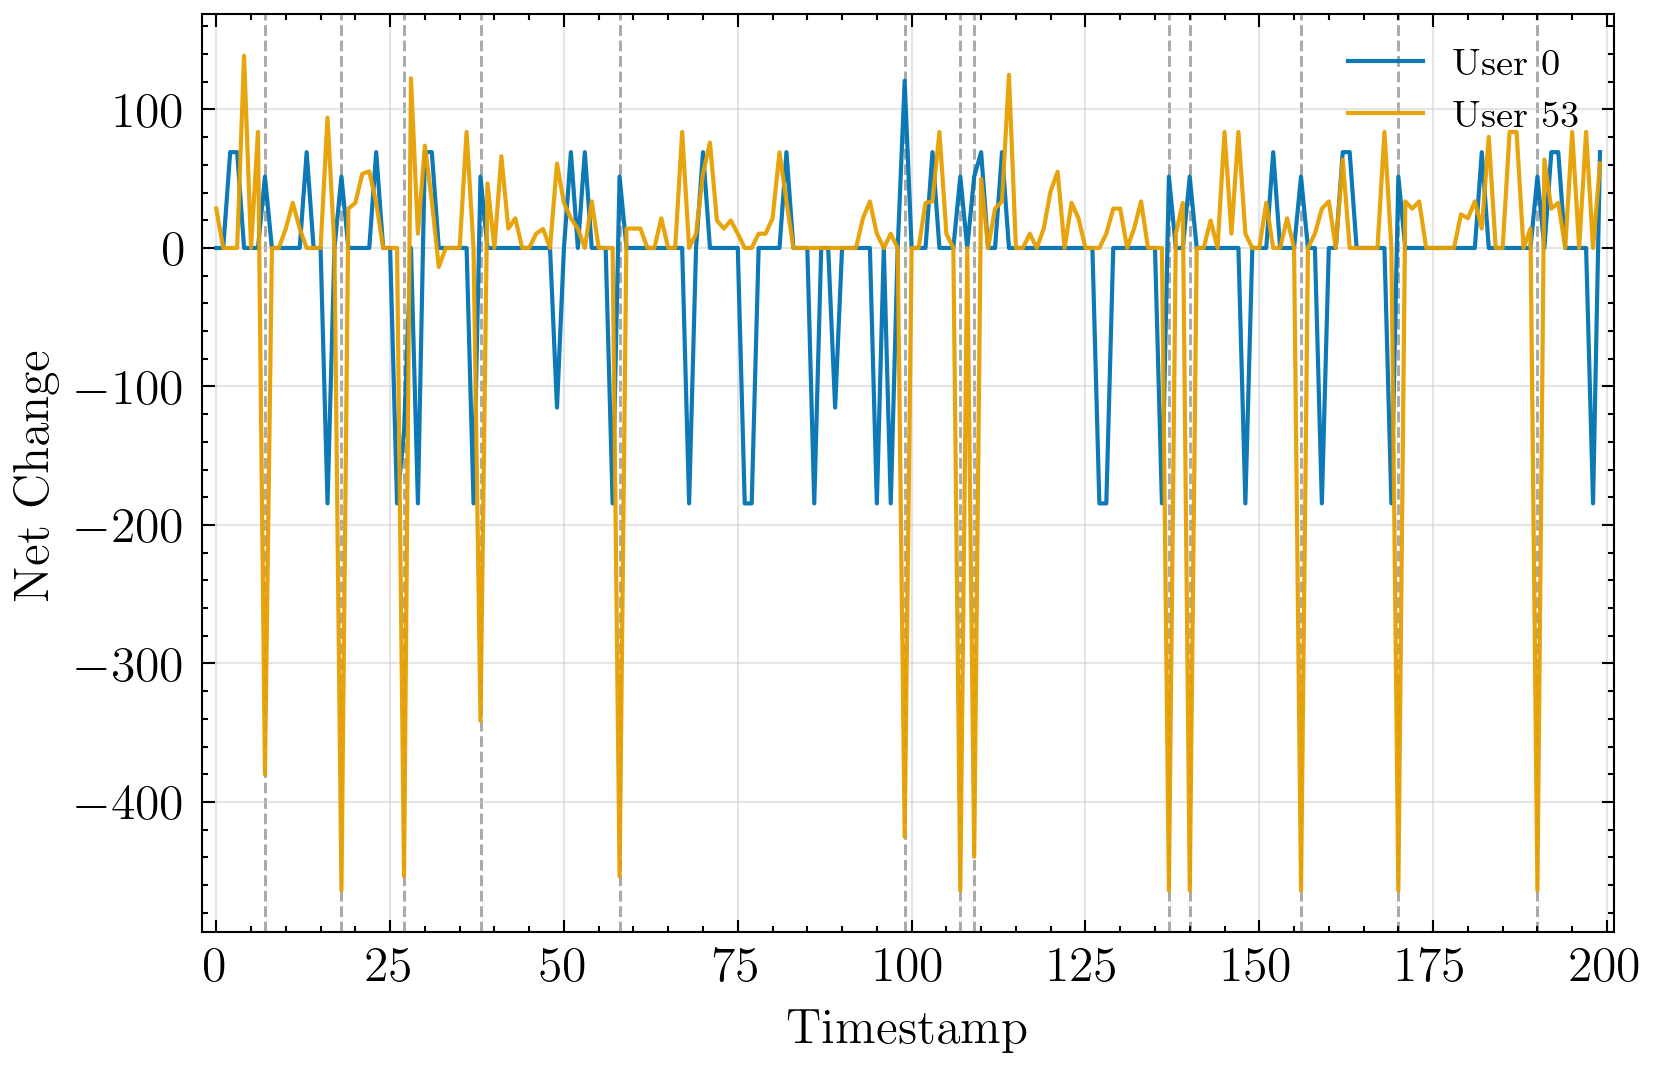

In [48]:
dataset = df_net_change
user_a = 0
user_b = 53

series_a = dataset[user_a].dropna()
series_b = dataset[user_b].dropna()


# Filter mutual transactions
mutual_tx = transactions[
    ((transactions['SENDER_ACCOUNT_ID'] == user_a) & (transactions['RECEIVER_ACCOUNT_ID'] == user_b)) |
    ((transactions['SENDER_ACCOUNT_ID'] == user_b) & (transactions['RECEIVER_ACCOUNT_ID'] == user_a))
]

# Get the unique timestamps (assuming 'TIMESTAMP' is numeric or datetime)
mutual_timestamps = mutual_tx['TIMESTAMP'].unique()

# Make sure timestamps are in the index format of the series (if needed)
# You may need to align formats if residuals use datetime or int indices

# # Now plot with highlights
# plt.figure(figsize=(12, 7.5), dpi=180)
# plt.plot(series_a, label=f"User {user_a}", alpha=0.7, color='green')
# plt.plot(series_b, label=f"User {user_b}", alpha=0.7, color='orange')

# # Highlight mutual transaction timestamps
# for t in mutual_timestamps:
#     plt.axvline(x=t, color='red', linestyle='--', alpha=0.4)

# plt.legend()
# plt.title(f"Net Change Time Series: User {user_a} vs User {user_b}\n(red lines = mutual transactions)")
# plt.xlabel("Timestamp")
# plt.ylabel("Net change")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

fig, ax = plt.subplots(figsize=figsize, constrained_layout=True, dpi=300)

# Main series
ax.plot(series_a.index, series_a.values, label=f'User {user_a}', color=C_A, alpha=0.95)
ax.plot(series_b.index, series_b.values, label=f'User {user_b}', color=C_B, alpha=0.95)

# Subtle event markers behind data (thin, semi-transparent, clipped to axes)
ymin, ymax = ax.get_ylim()
for t in mutual_timestamps:
    ax.axvline(x=t, color=C_EVT, linestyle='--', lw=0.7, alpha=0.9, zorder=0)

# Labels & cosmetics
ax.set_xlabel('Timestamp')          
ax.set_ylabel('Net Change')      
ax.grid(axis='y', color='#cccccc', linewidth=0.5, alpha=0.5)
ax.grid(axis='x', color='#cccccc', linewidth=0.5, alpha=0.5, visible=True)
ax.legend(loc='upper right', framealpha=0.85)
ax.margins(x=0.01)                  # minimal horizontal padding

plt.show()